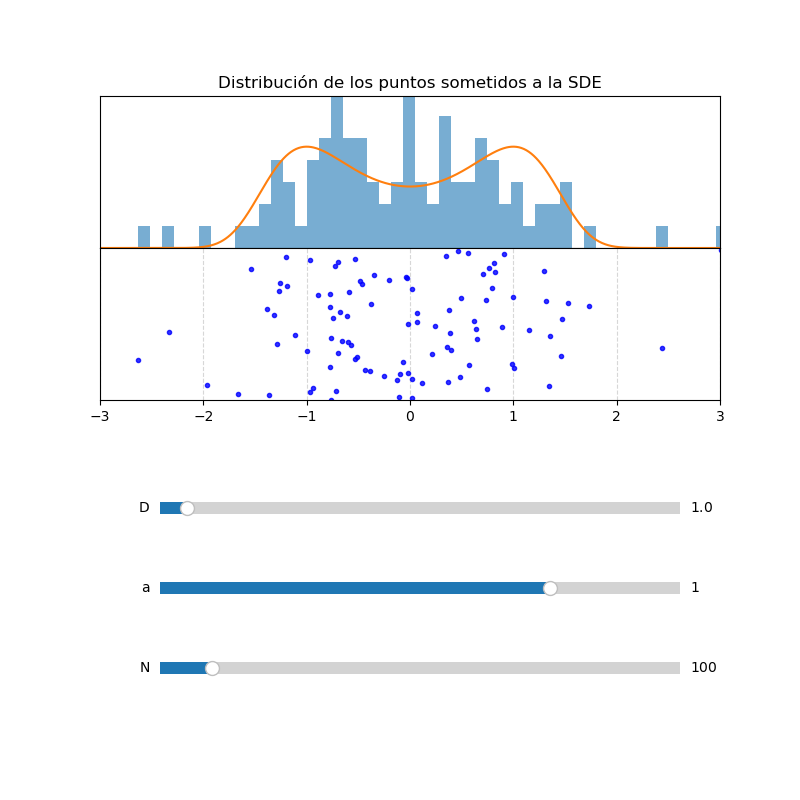

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad

# 1. Definimos el sistema de ecuaciones diferenciales estocásticas
def actualizar_posiciones(X, a, D, dt=0.005):
    N = X.shape[0]
    dxdt = a * X - X**3 + np.sqrt(D) * np.random.standard_normal(N) / np.sqrt(dt)
    X_nuevo = X + dt * dxdt

    return X_nuevo

# Configuración inicial de la simulación
N_init = 100
a_init = 1
D_init = 1
X = np.random.standard_normal(N_init)
Y = np.arange(N_init)

def pdf(x, a, D):
    x_array = np.asarray(x)
    func_nnorm = lambda t: np.exp((a * t**2 - 0.5 * t**4) / D)
    norma, error = quad(func_nnorm, -np.inf, np.inf)
    resultado = func_nnorm(x_array) / norma
    return resultado

# Configuración de la ventana gráfica
fig, [ax_hist, ax_dots] = plt.subplots(nrows=2, figsize=(8, 8))
plt.subplots_adjust(bottom=0.5, hspace=0)

puntos, = ax_dots.plot(X, Y, 'b.', alpha=0.8)
ax_dots.set_xlim(-3, 3)
ax_dots.set_ylim(0, N_init)
ax_dots.grid(True, linestyle='--', alpha=0.5)
ax_dots.set_yticks([])

pesos_iniciales, bins, patches = ax_hist.hist(X, bins=50, density=True, alpha=0.6)
x_range = np.linspace(-3, 3, 1000)
pdf_plot, = ax_hist.plot(x_range, pdf(x_range, a_init, D_init))

ax_hist.set_xlim(-3, 3)
ymax = pdf(x_range, a_init, D_init).max()
ax_hist.set_ylim(0, ymax * 1.5)

ax_hist.set_xticks([])
ax_hist.set_yticks([])
ax_hist.set_title("Distribución de los puntos sometidos a la SDE")

# Creación de los sliders
ax_a = plt.axes([0.2, 0.25, 0.65, 0.03])
ax_D = plt.axes([0.2, 0.35, 0.65, 0.03])
ax_N = plt.axes([0.2, 0.15, 0.65, 0.03])
plt.text(5, 0.1, r"SDE: $\dot{x} = ax-x^3 + \sqrt{D}\xi(t)$", ha='center')

slider_a = Slider(ax=ax_a, label="a", valmin=-2, valmax=2, valinit=a_init)
slider_D = Slider(ax=ax_D, label="D", valmin=0.5, valmax=10, valinit=D_init)
slider_N = Slider(ax=ax_N, label="N", valmin=0, valmax=1000, valinit=N_init, valstep=10)

# Creación de la animación
def update(frame):
    global X, Y
    a = slider_a.val
    D = slider_D.val
    N_actual = len(X)
    N_nuevo = int(slider_N.val)

    if N_nuevo < N_actual:
        X = X[:N_nuevo]
    elif N_nuevo > N_actual:
        N_faltante = N_nuevo - N_actual
        X_faltante = np.random.standard_normal(N_faltante)
        X = np.concatenate((X, X_faltante))

    X = actualizar_posiciones(X, a, D)
    if N_nuevo != N_actual:
        Y = np.arange(N_nuevo)
        if N_nuevo == 0:
            ax_dots.set_ylim(0, 10)
        else:
            ax_dots.set_ylim(0, N_nuevo)

    puntos.set_data(X, Y)
    pdf_plot.set_data(x_range, pdf(x_range, a, D))
    ymax = pdf(x_range, a, D).max()
    ax_hist.set_ylim(0, ymax * 1.5)

    with np.errstate(divide='ignore', invalid='ignore'):
        nuevas_alturas, _ = np.histogram(X, bins=bins, density=True)
    nuevas_alturas = np.nan_to_num(nuevas_alturas)

    for patch, altura in zip(patches, nuevas_alturas):
        patch.set_height(altura)
    
    return puntos, *patches, pdf_plot

animation = FuncAnimation(fig, update, interval=20, cache_frame_data=False)

plt.show()